In [1]:
import tensorflow as tf
import numpy as np
import scipy
import cv2
import os 
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop
import keras

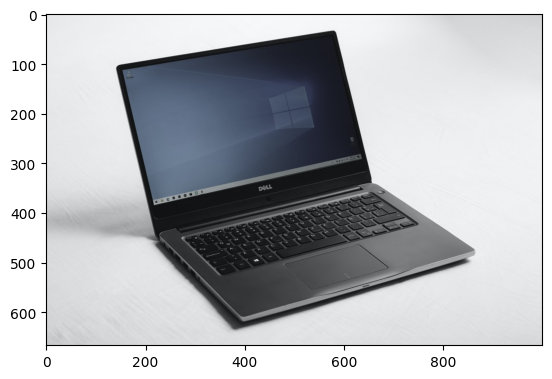

In [2]:
img = image.load_img("C:/Users/Nidhi Dhameliya/Desktop/jupyter/first/imagedata/training/laptop/1.jpg")
plt.imshow(img)

In [4]:
cv2.imread("C:/Users/Nidhi Dhameliya/Desktop/jupyter/first/imagedata/training/laptop/1.jpg").shape

(667, 1000, 3)

In [5]:
cv2.imread("C:/Users/Nidhi Dhameliya/Desktop/jupyter/first/imagedata/training/laptop/1.jpg")

array([[[234, 232, 231],
        [234, 232, 231],
        [234, 232, 231],
        ...,
        [210, 208, 207],
        [210, 208, 207],
        [210, 208, 207]],

       [[234, 232, 231],
        [234, 232, 231],
        [234, 232, 231],
        ...,
        [211, 209, 208],
        [211, 209, 208],
        [211, 209, 208]],

       [[234, 232, 231],
        [234, 232, 231],
        [234, 232, 231],
        ...,
        [211, 209, 208],
        [211, 209, 208],
        [211, 209, 208]],

       ...,

       [[204, 202, 201],
        [204, 202, 201],
        [203, 201, 200],
        ...,
        [218, 216, 215],
        [218, 216, 215],
        [219, 217, 216]],

       [[204, 202, 201],
        [204, 202, 201],
        [203, 201, 200],
        ...,
        [217, 215, 214],
        [218, 216, 215],
        [218, 216, 215]],

       [[204, 202, 201],
        [204, 202, 201],
        [203, 201, 200],
        ...,
        [217, 215, 214],
        [217, 215, 214],
        [216, 214, 213]]

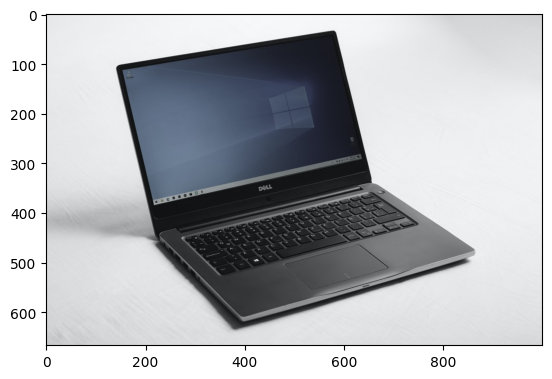

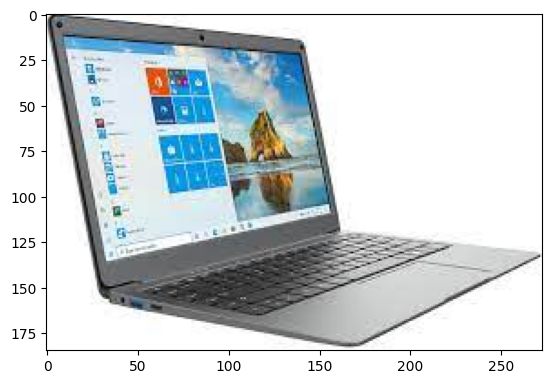

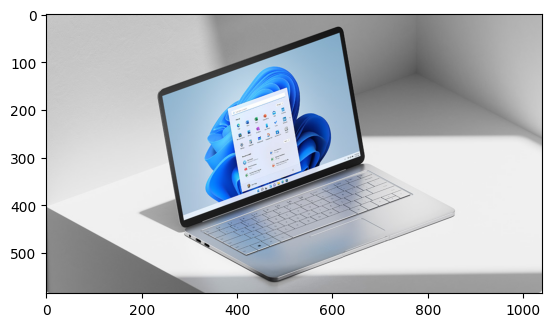

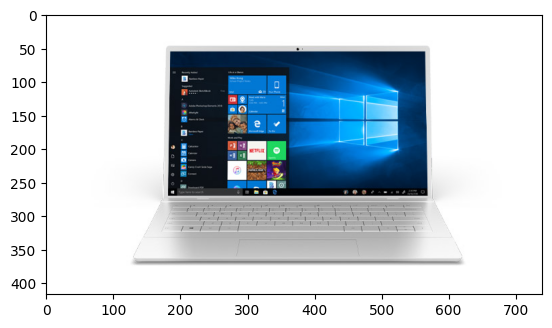

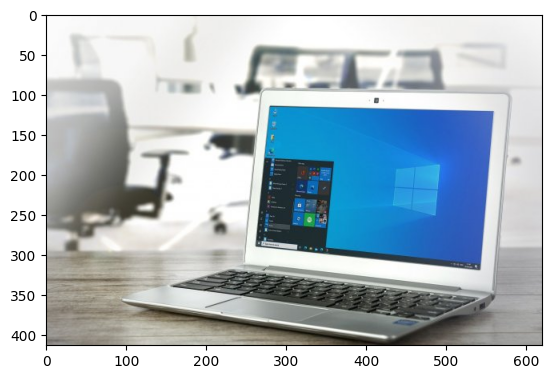

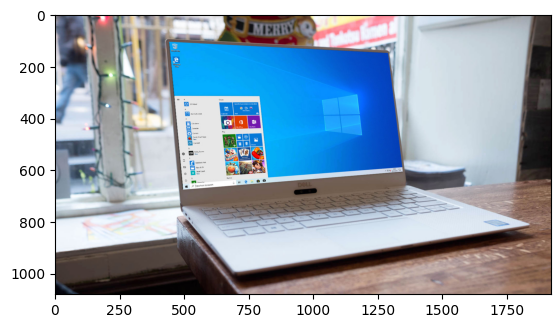

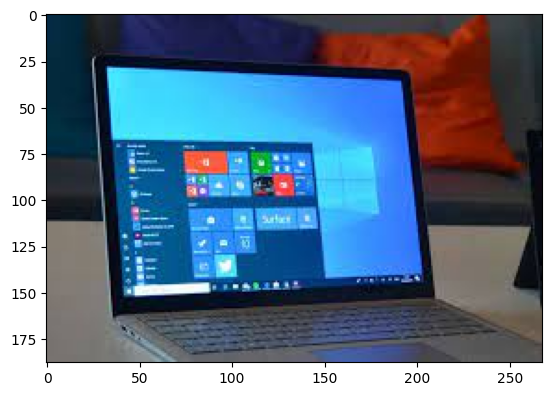

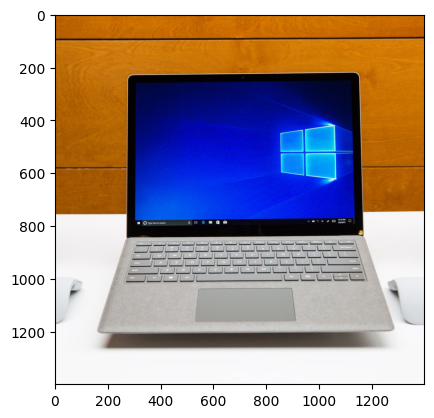

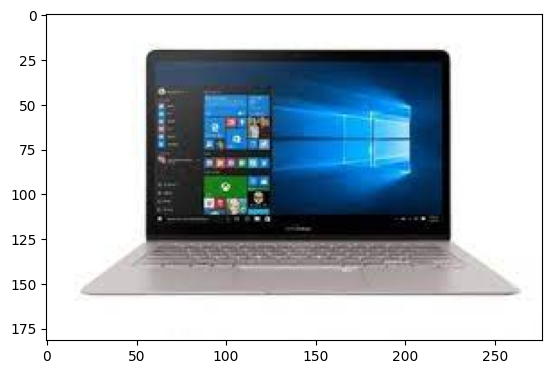

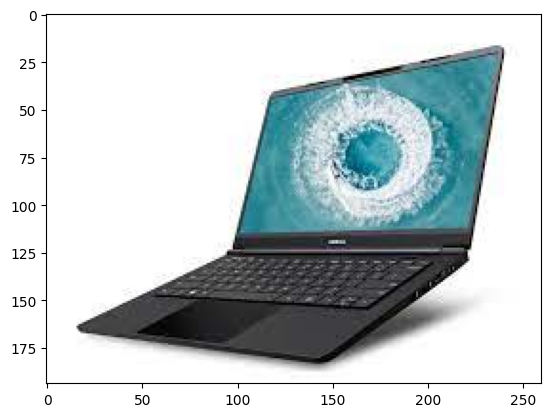

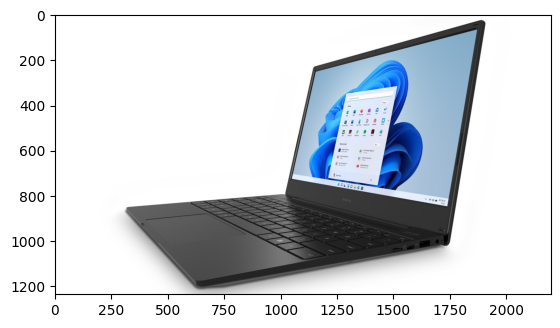

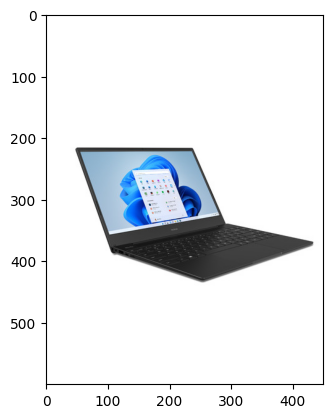

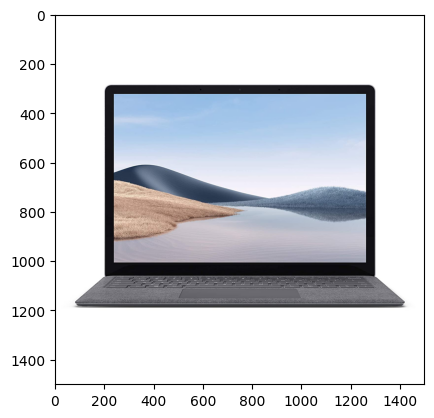

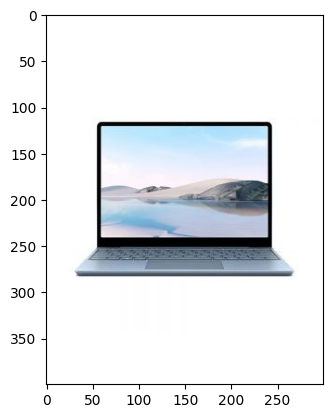

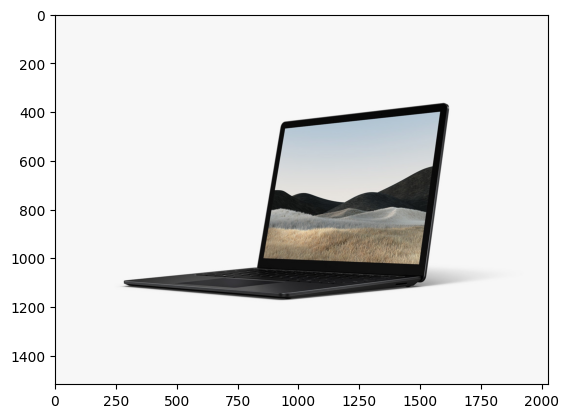

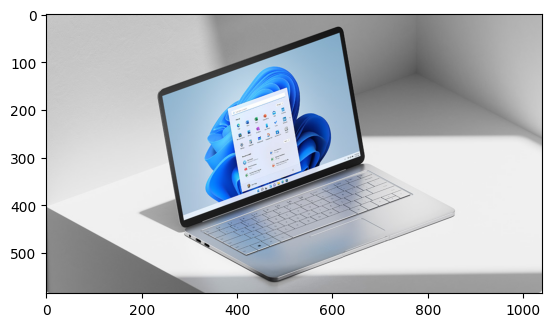

In [6]:
dir_path = "C:/Users/Nidhi Dhameliya/Desktop/jupyter/first/imagedata/training/laptop"
for i in os.listdir(dir_path):
    img = image.load_img(dir_path+"//"+i)
    plt.imshow(img)
    plt.show()

In [7]:

train = ImageDataGenerator(rescale=1/255)
validation = ImageDataGenerator(rescale=1/255)

In [8]:
traning_dataset = train.flow_from_directory('C:/Users/Nidhi Dhameliya/Desktop/jupyter/first/imagedata/training',target_size=(200,200),batch_size=3,
                                         class_mode='binary')

validation_dataset = validation.flow_from_directory('C:/Users/Nidhi Dhameliya/Desktop/jupyter/first/imagedata/validation',target_size=(200,200),batch_size=3,
                                         class_mode='binary')

Found 31 images belonging to 2 classes.
Found 31 images belonging to 2 classes.


In [9]:
traning_dataset.class_indices

{'laptop': 0, 'mobile': 1}

In [10]:
traning_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1])

In [11]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Input

model = Sequential([
    Input(shape=(200, 200, 3)),  # Define input shape here
    Conv2D(16, (3, 3), activation='relu'),
    MaxPool2D(2, 2),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid')
])


In [12]:
model.compile(loss='binary_crossentropy',optimizer=RMSprop(learning_rate=0.01),metrics=['accuracy'])

In [15]:
a = model.fit(traning_dataset,steps_per_epoch=3,epochs=50,validation_data=validation_dataset)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 576ms/step - accuracy: 1.0000 - loss: 3.3694e-07 - val_accuracy: 1.0000 - val_loss: 1.5703e-05
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 491ms/step - accuracy: 1.0000 - loss: 4.7250e-06 - val_accuracy: 1.0000 - val_loss: 1.5224e-05
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 495ms/step - accuracy: 1.0000 - loss: 3.2878e-05 - val_accuracy: 1.0000 - val_loss: 1.0382e-05
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 381ms/step - accuracy: 1.0000 - loss: 1.4841e-05 - val_accuracy: 1.0000 - val_loss: 9.2574e-06
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 490ms/step - accuracy: 1.0000 - loss: 8.3450e-06 - val_accuracy: 1.0000 - val_loss: 8.4844e-06
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 499ms/step - accuracy: 1.0000 - loss: 1.4482e-05 - val_accuracy: 1.0000 - val_loss: 7.0875e-06
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step - accuracy: 1.0000 - loss: 6.2159e-06 - val_accuracy: 1.0000 - val_loss: 5.7646e-06
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 410ms/step - accuracy: 

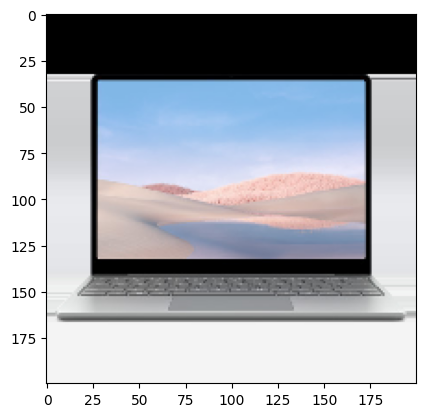

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
[[0.]]


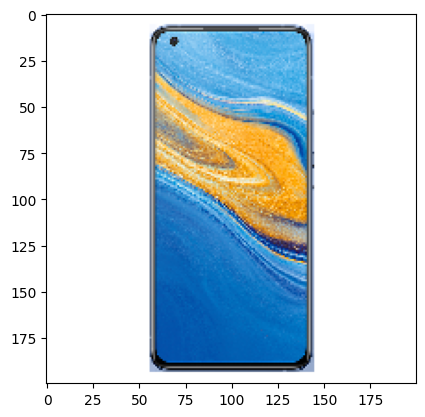

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
[[1.]]


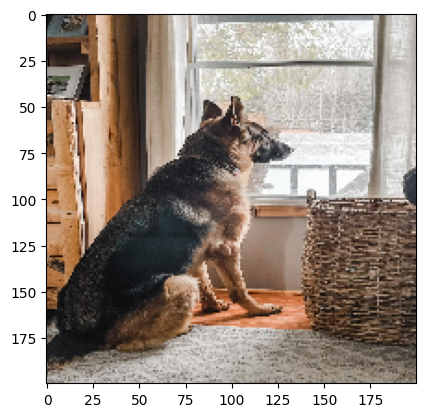

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
[[0.]]


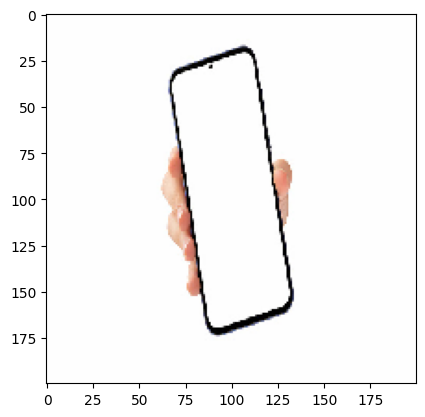

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[[1.]]


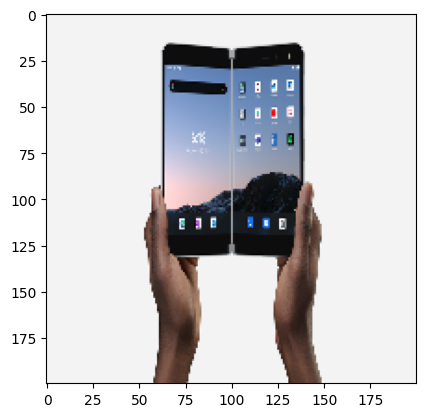

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
[[0.]]


In [17]:
dir_path = 'C:/Users/Nidhi Dhameliya/Desktop/jupyter/first/imagedata/testing'

for i in os.listdir(dir_path):
    img = image.load_img(dir_path+"//"+i,target_size=(200,200))
    plt.imshow(img)
    plt.show()
    
    IA = image.img_to_array(img)
    IA = np.expand_dims(IA,axis=0)
    testimg = np.vstack([IA])
    ans = model.predict(testimg)
    print(ans)